# Testing of reprojections

## Download country shapefiles

In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import cartopy
import geopandas as gpd


ne = cartopy.io.shapereader.natural_earth(
    resolution="10m", category="cultural", name="admin_0_countries"
)
ne_gdf = gpd.read_file(ne)
ne_gdf

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,ADMIN,ADM0_A3,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,Indonesia,IDN,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,Malaysia,MYS,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,Chile,CHL,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,Admin-0 country,0,3,Bolivia,BOL,0,2,Sovereign country,Bolivia,BOL,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,Admin-0 country,0,2,Peru,PER,0,2,Sovereign country,Peru,PER,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,Admin-0 country,0,4,China,CH1,1,2,Country,Macao S.A.R,MAC,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((113.5586 22.16303, 113.56943 2..."
254,Admin-0 country,6,5,Australia,AU1,1,2,Dependency,Ashmore and Cartier Islands,ATC,...,None,None,None,None,None,None,None,None,None,"POLYGON ((123.59702 -12.42832, 123.59775 -12.4..."
255,Admin-0 country,6,8,Bajo Nuevo Bank (Petrel Is.),BJN,0,2,Indeterminate,Bajo Nuevo Bank (Petrel Is.),BJN,...,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,"POLYGON ((-79.98929 15.79495, -79.98782 15.796..."
256,Admin-0 country,6,5,Serranilla Bank,SER,0,2,Indeterminate,Serranilla Bank,SER,...,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,"POLYGON ((-78.63707 15.86209, -78.64041 15.864..."


<Axes: >

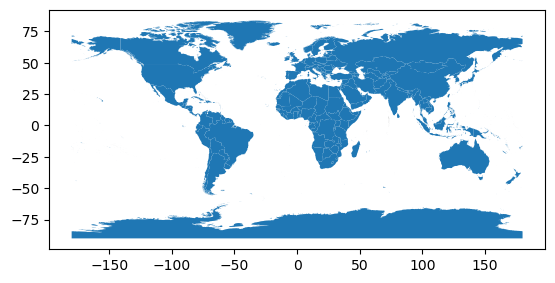

In [3]:
ne_gdf.plot()

## Load GRIB data

We can tell `cfgrib` that we want the `projString`.
This can be used as CRS to be inserted into the rioxarray CRS.

In [5]:
import xarray as xr
import odc.geo.xr  # noqa: F401

ds = xr.open_dataset(
    "/Users/ldr.riedel/experiments/climada-ce/data/hazard/efas-2021.grib",
    chunks="auto",
    decode_times=True,
    # decode_coords="all",
    # backend_kwargs={"read_keys": ["projString"]},
    # engine="rasterio",
    engine="cfgrib",
)
ds

/Users/ldr.riedel/miniforge3/envs/climada_env_3.12/lib/python3.12/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 486MB
Dimensions:     (time: 124, y: 950, x: 1000)
Coordinates:
  * time        (time) datetime64[ns] 992B 2021-07-01 ... 2021-07-31T18:00:00
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    latitude    (y, x) float64 8MB dask.array<chunksize=(950, 1000), meta=np.ndarray>
    longitude   (y, x) float64 8MB dask.array<chunksize=(950, 1000), meta=np.ndarray>
    valid_time  (time) datetime64[ns] 992B dask.array<chunksize=(124,), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    dis06       (time, y, x) float32 471MB dask.array<chunksize=(81, 627, 659), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-30T10:01 GRIB to CDM+CF via cfgrib-0.9.1...

In [13]:
ds.odc._state

GeoState(spatial_dims=('y', 'x'), crs_coord=None, transform=None, crs=None, geobox=None, gcp=None, x=None, y=None, z=None)

In [16]:
ds["latitude"].to_numpy().shape

(950, 1000)

In [12]:
ds.odc.geobox

In [10]:
ds.rio.crs

In [165]:
ds["band_data"]

<xarray.DataArray 'band_data' (band: 124, y: 950, x: 1000)> Size: 942MB
dask.array<open_dataset-band_data, shape=(124, 950, 1000), dtype=float64, chunksize=(124, 135, 1000), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 992B 1 2 3 4 5 6 7 ... 118 119 120 121 122 123 124
  * x            (x) float64 8kB -1.819e+06 -1.814e+06 ... 3.171e+06 3.176e+06
  * y            (y) float64 8kB 2.287e+06 2.282e+06 ... -2.453e+06 -2.458e+06
    spatial_ref  int64 8B ...
Attributes:
    GRIB_UNIT:                  unknown
    GRIB_COMMENT:               unknown
    GRIB_ELEMENT:               unknown
    GRIB_SHORT_NAME:            unknown
    GRIB_REF_TIME:              1625097600
    GRIB_VALID_TIME:            0
    GRIB_FORECAST_SECONDS:      0
    GRIB_DISCIPLINE:            1(Hydrological)
    GRIB_IDS:                   CENTER=98(ECMWF) SUBCENTER=0 MASTER_TABLE=25 ...
    GRIB_PDS_PDTN:              72
    GRIB_PDS_TEMPLATE_NUMBERS:  0 7 0 19 0 98 1 0 147 1 0 0 0 1 0 0 0 0 1 255...
    long_name:                  unknown

In [156]:
proj_string = ds["dis06"].attrs["GRIB_projString"]

KeyError: "No variable named 'dis06'. Variables on the dataset include ['band', 'x', 'y', 'spatial_ref', 'band_data']"

In [141]:
import pyproj

ds.rio.write_crs(proj_string, inplace=True)
ds.rio.crs

CRS.from_wkt('PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6378137,298.257220143428]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",52],PARAMETER["longitude_of_center",10],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]')

However, this does not yield a GeoBox.
Also, the x/y coordinates are not decoded.

In [143]:
ds.odc

In [111]:
ds.rio.transform(recalc=True)

Affine(1.0, 0.0, 0.0,
       0.0, 1.0, 0.0)

### Load with rasterio

Alternatively, we can load the GRIB file with `libgdal-grib` (conda-forge only) and rasterio.
This will give us a GeoBox and better (?) CRS information with x/y coordinates decoded.
However, the time dimension and band data are not decoded.

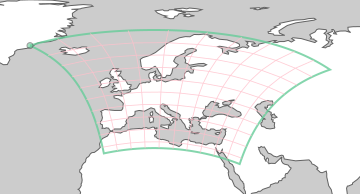

In [ ]:
import rioxarray
import odc.geo.xr  # noqa: F401

ds_rio = rioxarray.open_rasterio(
    "/Users/ldr.riedel/experiments/climada-ce/data/hazard/efas-2021.grib"
)
ds_rio.odc.geobox

In [117]:
ds_rio.rio.crs

CRS.from_wkt('PROJCS["unnamed",GEOGCS["Coordinate System imported from GRIB file",DATUM["unnamed",SPHEROID["GRS80",6378137,298.257222101]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",52],PARAMETER["longitude_of_center",10],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["Metre",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]')

In [120]:
ds_rio.rio.crs == ds.rio.crs

False

In [121]:
ds_rio.rio.transform()

Affine(5000.0, 0.0, -1821000.0212503993,
       0.0, -5000.0, 2289999.9546102225)

## Attempt resampling

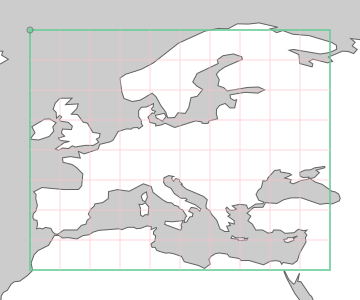

In [157]:
target_box = odc.geo.GeoBox.from_bbox((-10, 30, 40, 70), resolution=0.1)
target_box

In [158]:
# ds.odc.reload()
ds_repr = ds.odc.reproject(target_box)

In [ ]:
ds_repr.plot

## Load NetCDF

In [ ]:
import xarray as xr
import rioxarray
import odc.geo.xr  # noqa: F401

ds = xr.open_dataset(
    "/Users/ldr.riedel/experiments/climada-ce/data/hazard/efas-2021.nc",
    chunks="auto",
    decode_coords="all",
    engine="netcdf4",
)
ds

<xarray.Dataset> Size: 7GB
Dimensions:     (valid_time: 124, latitude: 2970, longitude: 4530)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 992B 2021-07-01T06:00:00 ... 2021...
    surface     float64 8B ...
  * latitude    (latitude) float64 24kB 72.24 72.22 72.21 ... 22.79 22.78 22.76
  * longitude   (longitude) float64 36kB -25.24 -25.23 -25.21 ... 50.22 50.24
Data variables:
    dis06       (valid_time, latitude, longitude) float32 7GB dask.array<chunksize=(32, 744, 1134), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-06-27T10:07 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
ds["dis06"]

<xarray.DataArray 'dis06' (valid_time: 124, latitude: 2970, longitude: 4530)> Size: 7GB
dask.array<open_dataset-dis06, shape=(124, 2970, 4530), dtype=float32, chunksize=(32, 744, 1134), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 992B 2021-07-01T06:00:00 ... 2021...
    surface     float64 8B ...
  * latitude    (latitude) float64 24kB 72.24 72.22 72.21 ... 22.79 22.78 22.76
  * longitude   (longitude) float64 36kB -25.24 -25.23 -25.21 ... 50.22 50.24
Attributes: (12/32)
    GRIB_paramId:                             240023
    GRIB_dataType:                            sfo
    GRIB_numberOfPoints:                      13454100
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avg
    ...                                       ...
    GRIB_name:                                Mean discharge in the last 6 hours
    GRIB_shortName:                           dis06
    GRIB_units:                               m**3 s**-1
    long_name:                                Mean discharge in the last 6 hours
    units:                                    m**3 s**-1
    standard_name:                            unknown

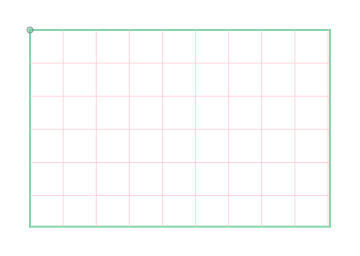

In [4]:
ds.odc.geobox

In [5]:
ds = ds.odc.assign_crs("EPSG:4326")
ds.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

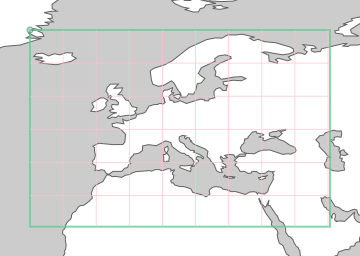

In [6]:
ds.odc.geobox

In [18]:
ds.odc.geobox.resolution

Resolution(x=0.0166667, y=-0.0166667)

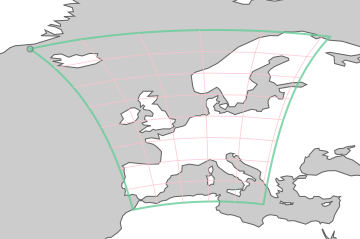

In [7]:
target_box = odc.geo.GeoBox.from_bbox(
    (-1_622_389, 622_317, 943_693, 4_606_629), resolution=1_000, crs="ESRI:102031"
)
target_box

In [8]:
data = ds["dis06"].max(dim="valid_time")

In [9]:
data_repr = data.odc.reproject(target_box)

In [10]:
# data_repr.plot()

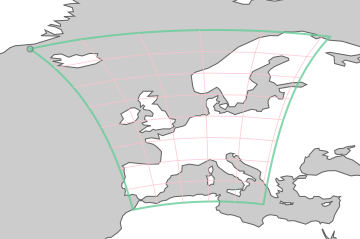

In [11]:
data_repr.odc.geobox

In [12]:
geo_deu = ne_gdf.loc[ne_gdf["ADM0_A3"] == "DEU", "geometry"]

In [13]:
import odc.geo.converters

data_repr_msk = data_repr.odc.mask(
    odc.geo.geom.unary_union(odc.geo.converters.from_geopandas(geo_deu))
)
data_repr_msk

<xarray.DataArray 'reproject-c09675ba4ddf4313bb7be51a75fce64d' (y: 3985, x: 2567)> Size: 41MB
dask.array<where, shape=(3985, 2567), dtype=float32, chunksize=(744, 1134), chunktype=numpy.ndarray>
Coordinates:
    surface      float64 8B ...
  * y            (y) float64 32kB 4.606e+06 4.606e+06 ... 6.235e+05 6.225e+05
  * x            (x) float64 21kB -1.622e+06 -1.622e+06 ... 9.425e+05 9.435e+05
    spatial_ref  int32 4B 0

In [14]:
data_repr_msk_dropna = data_repr_msk.dropna("x", how="all").dropna("y", how="all")
data_repr_msk_dropna

<xarray.DataArray 'reproject-c09675ba4ddf4313bb7be51a75fce64d' (y: 867, x: 633)> Size: 2MB
dask.array<getitem, shape=(867, 633), dtype=float32, chunksize=(664, 633), chunktype=numpy.ndarray>
Coordinates:
    surface      float64 8B ...
  * y            (y) float64 7kB 2.784e+06 2.782e+06 ... 1.918e+06 1.918e+06
  * x            (x) float64 5kB -2.865e+05 -2.855e+05 ... 3.445e+05 3.455e+05
    spatial_ref  int32 4B 0

/Users/ldr.riedel/miniforge3/envs/climada_env_3.12/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


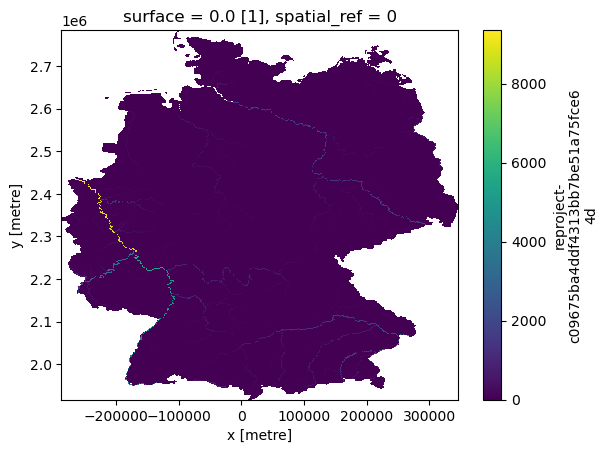

In [15]:
data_repr_msk_dropna.plot()

In [19]:
data_repr_crop = data_repr.odc.crop(
    odc.geo.geom.unary_union(odc.geo.converters.from_geopandas(geo_deu)),
    apply_mask=True,
)
data_repr_crop

<xarray.DataArray 'reproject-c09675ba4ddf4313bb7be51a75fce64d' (y: 869, x: 633)> Size: 2MB
dask.array<where, shape=(869, 633), dtype=float32, chunksize=(458, 633), chunktype=numpy.ndarray>
Coordinates:
    surface      float64 8B ...
  * y            (y) float64 7kB 2.786e+06 2.784e+06 ... 1.918e+06 1.918e+06
  * x            (x) float64 5kB -2.865e+05 -2.855e+05 ... 3.445e+05 3.455e+05
    spatial_ref  int32 4B 0

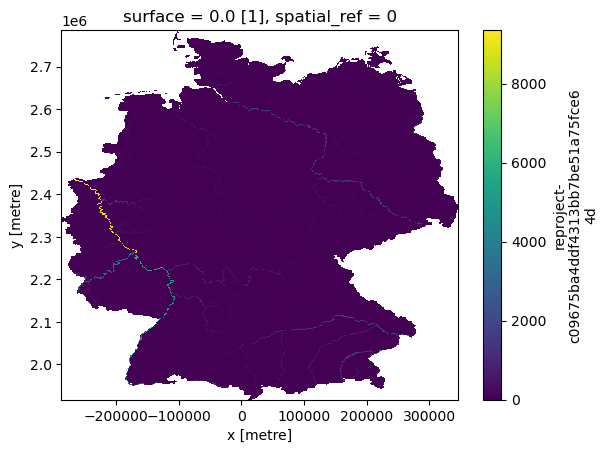

In [20]:
data_repr_crop.plot()

## Testing of small reprojections for NaNs

In [ ]:
import xarray as xr
import numpy as np
import odc.geo

ds = odc.geo.xr.wrap_xr(
    np.array([[0, 1, np.nan], [3, 4, 5], [6, np.nan, 8]]),
    odc.geo.GeoBox.from_bbox((50, 50, 51, 51), shape=(3, 3)),
)
ds

<xarray.DataArray (latitude: 3, longitude: 3)> Size: 72B
array([[ 0.,  1., nan],
       [ 3.,  4.,  5.],
       [ 6., nan,  8.]])
Coordinates:
  * latitude     (latitude) float64 24B 50.83 50.5 50.17
  * longitude    (longitude) float64 24B 50.17 50.5 50.83
    spatial_ref  int32 4B 4326

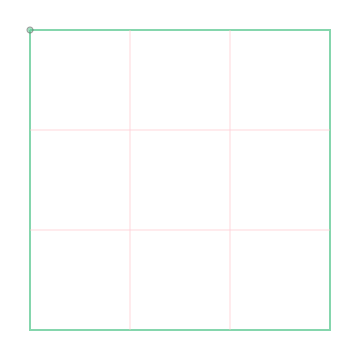

In [22]:
ds.odc.geobox

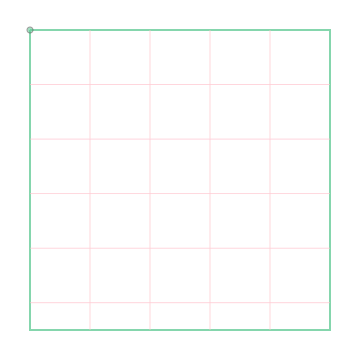

In [23]:
target_box = odc.geo.GeoBox.from_bbox((50, 50, 51.2, 51.2), shape=(11, 10), tight=False)
target_box

In [24]:
ds_repr = ds.odc.reproject(
    target_box,
    # resampling="nearest",
    resampling="bilinear",
    # dst_nodata=np.nan,
)
ds_repr.to_numpy().round(2)

array([[ nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan],
       [ nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan],
       [ nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan],
       [ nan, 0.  , 0.16, 0.52, 0.88, 1.  ,  nan,  nan,  nan,  nan],
       [ nan, 0.46, 0.62, 0.98, 1.34, 1.63,  nan,  nan,  nan,  nan],
       [ nan, 1.45, 1.61, 1.97, 2.33, 2.78,  nan,  nan,  nan,  nan],
       [ nan, 2.43, 2.59, 2.95, 3.31, 3.75, 4.29, 4.92, 5.  ,  nan],
       [ nan, 3.41, 3.49, 3.69, 3.92, 4.38, 4.89, 5.36, 5.41,  nan],
       [ nan, 4.39, 4.35, 4.25, 4.08, 4.89, 5.76, 6.34, 6.39,  nan],
       [ nan, 5.37, 5.32,  nan,  nan,  nan, 6.96, 7.34, 7.37,  nan],
       [ nan, 6.  , 6.  ,  nan,  nan,  nan, 8.  , 8.  , 8.  ,  nan]])

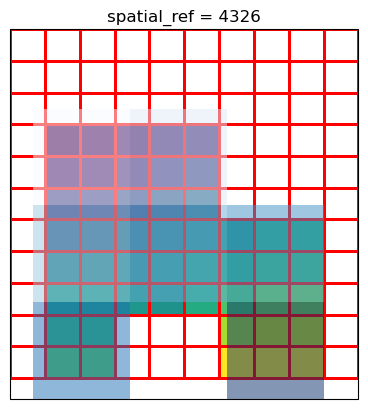

In [25]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})

ds_repr.plot.pcolormesh(ax=ax, cmap=None, edgecolors="r", add_colorbar=False)
ds.plot.pcolormesh(ax=ax, cmap="Blues", alpha=0.5, add_colorbar=False)

## Test functions

In [11]:
import cartopy
import geopandas as gpd


ne = cartopy.io.shapereader.natural_earth(
    resolution="10m", category="cultural", name="admin_0_countries"
)
ne_gdf = gpd.read_file(ne)
# ne_gdf

In [12]:
import xarray as xr
import sparse

ds = xr.open_mfdataset(
    "data/hazard/flood-maps/RP10/*.tif",
    chunks="auto",
    decode_coords="all",
    from_array_kwargs={
        "meta": sparse.GCXS,
        # "asarray": False,
        # "inline_array": True,
    },
    # inline_array=True,
)
ds = ds.squeeze().coarsen(x=10, y=10, boundary="trim").max()
ds

<xarray.Dataset> Size: 35MB
Dimensions:      (y: 2399, x: 3599)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 29kB -10.01 -10.0 -9.994 ... 19.96 19.97 19.97
  * y            (y) float64 19kB 60.0 59.99 59.98 59.97 ... 40.03 40.02 40.01
    spatial_ref  int64 8B 0
Data variables:
    band_data    (y, x) float32 35MB dask.array<chunksize=(563, 563), meta=np.ndarray>

In [13]:
countries = ["DEU", "CHE"]
ne_gdf[ne_gdf["ADM0_A3"].isin(countries)]

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,ADMIN,ADM0_A3,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
49,Admin-0 country,0,2,Germany,DEU,0,2,Sovereign country,Germany,DEU,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((13.81572 48.76643, 13.78586 48..."
91,Admin-0 country,0,4,Switzerland,CHE,0,2,Sovereign country,Switzerland,CHE,...,None,None,None,None,None,None,None,None,None,"POLYGON ((10.45381 46.86443, 10.44854 46.83223..."


In [14]:
import climadace

root = climadace.split_from_gdf(
    ds,
    ne_gdf[ne_gdf["ADM0_A3"].isin(countries)],
    groupy="ADM0_A3",
    keep_exterior=True,
    dropna=False,
)
root

<xarray.DataTree>
Group: /
├── Group: /CHE
│       Dimensions:      (y: 2399, x: 3599)
│       Coordinates:
│           band         int64 8B 1
│         * x            (x) float64 29kB -10.01 -10.0 -9.994 ... 19.96 19.97 19.97
│         * y            (y) float64 19kB 60.0 59.99 59.98 59.97 ... 40.03 40.02 40.01
│           spatial_ref  int64 8B 0
│       Data variables:
│           band_data    (y, x) float32 35MB dask.array<chunksize=(563, 563), meta=np.ndarray>
├── Group: /DEU
│       Dimensions:      (y: 2399, x: 3599)
│       Coordinates:
│           band         int64 8B 1
│         * x            (x) float64 29kB -10.01 -10.0 -9.994 ... 19.96 19.97 19.97
│         * y            (y) float64 19kB 60.0 59.99 59.98 59.97 ... 40.03 40.02 40.01
│           spatial_ref  int64 8B 0
│       Data variables:
│           band_data    (y, x) float32 35MB dask.array<chunksize=(563, 563), meta=np.ndarray>
└── Group: /_exterior
        Dimensions:      (y: 2399, x: 3599)
        Coordinates:
            band         int64 8B 1
          * x            (x) float64 29kB -10.01 -10.0 -9.994 ... 19.96 19.97 19.97
          * y            (y) float64 19kB 60.0 59.99 59.98 59.97 ... 40.03 40.02 40.01
            spatial_ref  int64 8B 0
        Data variables:
            band_data    (y, x) float32 35MB dask.array<chunksize=(563, 563), meta=np.ndarray>

In [6]:
from anytree import Resolver

res = Resolver()
res.get(root, "CHE").is_leaf

AttributeError: 'DataTree' object has no attribute 'separator'

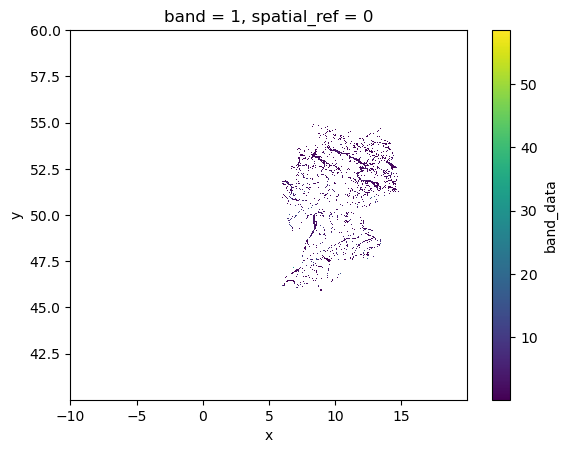

In [ ]:
from anytree import Resolver

res = Resolver()
res.get(root, "CHE").dset.combine_first(res.get(root, "DEU").dset)["band_data"].plot()

In [ ]:
from anytree import LevelOrderIter


print([node.name for node in LevelOrderIter(root, maxlevel=3)])

['root', 'CHE', 'DEU', '_exterior']


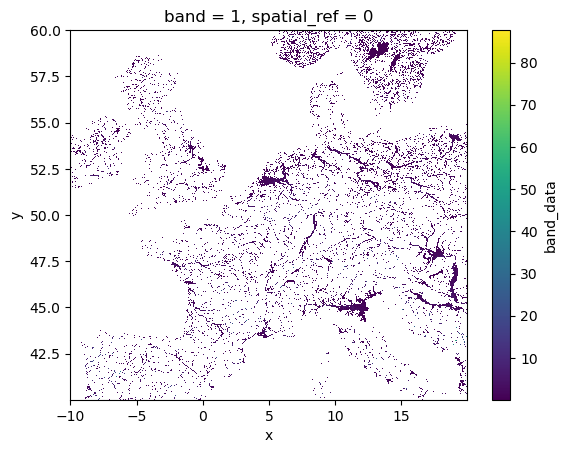

In [9]:
xr.merge([node.dataset for node in root.children.values()])["band_data"].plot()

In [15]:
node = climadace.merge_tree_dset(root)
node

CHE
DEU
_exterior


<xarray.DataTree>
Group: /
    Dimensions:      (y: 2399, x: 3599)
    Coordinates:
        band         int64 8B 1
      * x            (x) float64 29kB -10.01 -10.0 -9.994 ... 19.96 19.97 19.97
      * y            (y) float64 19kB 60.0 59.99 59.98 59.97 ... 40.03 40.02 40.01
        spatial_ref  int64 8B 0
    Data variables:
        band_data    (y, x) float32 35MB dask.array<chunksize=(563, 563), meta=np.ndarray>

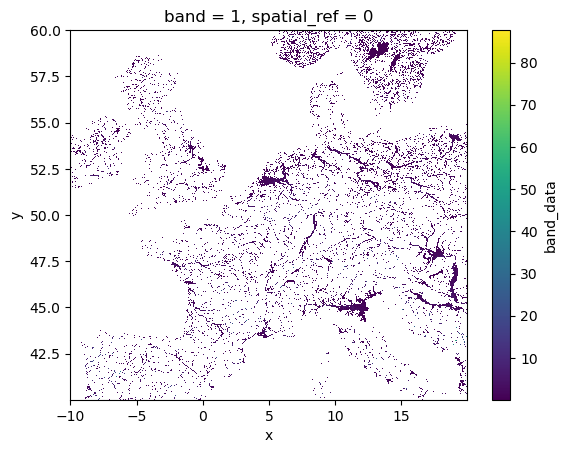

In [17]:
node.dataset["band_data"].plot()

In [ ]:
node.children = []
node.children

()

In [ ]:
node.dset["band_data"].plot()